<a href="https://colab.research.google.com/github/PatJosh-Codes/AI-Image-Detector/blob/main/AI_Generated_image_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 59ms/step - accuracy: 0.9115 - loss: 0.2572 - val_accuracy: 0.9194 - val_loss: 0.2262
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 54ms/step - accuracy: 0.9290 - loss: 0.1858 - val_accuracy: 0.9358 - val_loss: 0.1708
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.9389 - loss: 0.1617 - val_accuracy: 0.9411 - val_loss: 0.1570
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.9457 - loss: 0.1455 - val_accuracy: 0.9418 - val_loss: 0.1571
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9508 - loss: 0.1316 - val_accuracy: 0.9461 - val_loss: 0.1507


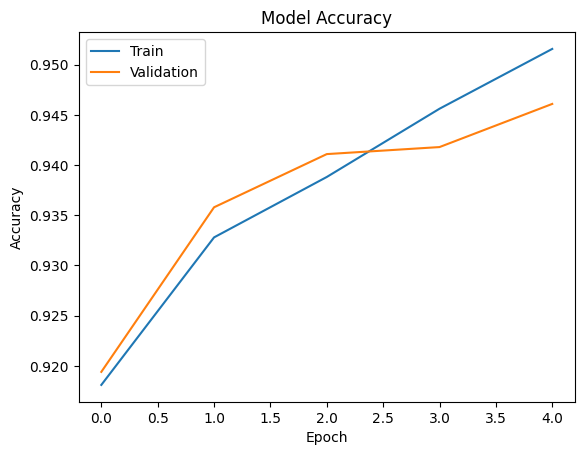

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Confusion Matrix:
[[8881  119]
 [ 420  580]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9000
           1       0.83      0.58      0.68      1000

    accuracy                           0.95     10000
   macro avg       0.89      0.78      0.83     10000
weighted avg       0.94      0.95      0.94     10000



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Load built-in dataset (automatic download)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Convert to binary classification
train_labels = (train_labels == 0).astype(int)
test_labels = (test_labels == 0).astype(int)

# Normalize
train_images = train_images / 255.0
test_images = test_images / 255.0

# Build CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(train_images, train_labels,
                    epochs=5,
                    validation_data=(test_images, test_labels))


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


predictions = model.predict(test_images)
y_pred = (predictions > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(test_labels, y_pred))

print("\nClassification Report:")
print(classification_report(test_labels, y_pred))